# H2 ablation: ordinary prose

Each passage is a Wikipedia paragraph that answers its question in text, with
no infobox and no metadata block, so the adapters are measured here on input
carrying none of the structure they were trained to be invariant to.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from fsr.comparison import NI_MARGIN
from fsr.formats import FORMAT_NAMES
from fsr.h2_results import (
    prose_available,
    prose_matrix,
    prose_table,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.45,
        "axes.edgecolor": "0.3",
        "axes.linewidth": 0.9,
    }
)

BAR_FILL = sns.color_palette("pastel")[0]
BAR_EDGE = sns.color_palette("muted")[0]
MUTED_FILL = "0.88"
MUTED_EDGE = "0.6"
RULE = "0.35"
ERROR = "0.45"
DIVERGING = "RdBu_r"

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "data" / "nq"
FIG_DIR = ROOT / "notebooks" / "h2" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MRR_LABEL = "prose MRR"
DELTA_LABEL = "$\\Delta$ prose MRR against the untrained model"


def save(fig, name):
    """Write the figure as a vector PDF for the thesis and a PNG to read."""
    fig.tight_layout()
    for suffix in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{suffix}", bbox_inches="tight")


def fills(flags):
    """Return the fill and edge colour of each mark, by whether it resolved."""
    return (
        [BAR_FILL if f else MUTED_FILL for f in flags],
        [BAR_EDGE if f else MUTED_EDGE for f in flags],
    )


SLUGS = prose_available(DATA_ROOT)
prose = prose_table(DATA_ROOT, SLUGS)

print(f"{len(SLUGS)} models, {len(FORMAT_NAMES)} folds, two arms each")
print(f"non-inferiority margin: {NI_MARGIN}")
print(
    f"arms that kept their quality: {int(prose['arms_kept'].sum())}/{len(SLUGS) * 10}"
)

6 models, 5 folds, two arms each
non-inferiority margin: 0.03
arms that kept their quality: 60/60


## Ranking quality

In [2]:
prose[
    [
        "weight",
        "baseline_mrr",
        "control_mrr",
        "winner_mrr",
        "control_delta",
        "winner_delta",
        "arms_kept",
    ]
].round(4)

,weight,baseline_mrr,control_mrr,winner_mrr,control_delta,winner_delta,arms_kept
model,,,,,,,
MiniLM-L6,1.0,0.8961,0.9093,0.9114,0.0132,0.0153,10
MiniLM-L12,0.1,0.8999,0.9188,0.9215,0.0189,0.0216,10
bge-base,1.0,0.8539,0.9064,0.9224,0.0525,0.0685,10
bge-v2-m3,1.0,0.9481,0.9489,0.9549,0.0008,0.0069,10
mxbai-v1,0.1,0.9222,0.9402,0.9398,0.0180,0.0176,10
jina-v2,0.1,0.9426,0.9479,0.9538,0.0053,0.0112,10


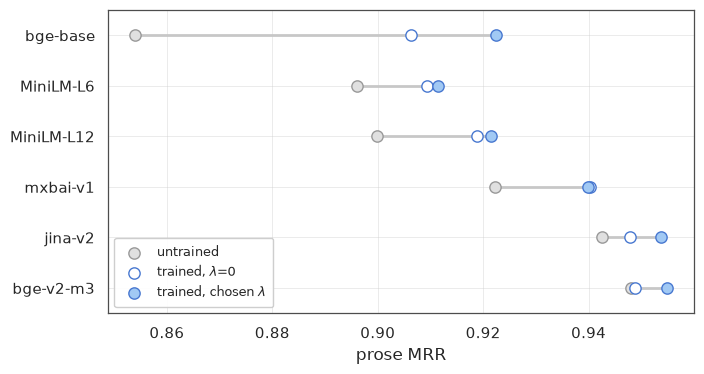

In [3]:
order = prose.sort_values("baseline_mrr").index
rows = prose.loc[order]
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.hlines(y, rows["baseline_mrr"], rows["winner_mrr"], color="0.78", lw=2.0, zorder=1)
for column, colour, edge, label in (
    ("baseline_mrr", MUTED_FILL, MUTED_EDGE, "untrained"),
    ("control_mrr", "white", BAR_EDGE, "trained, $\\lambda$=0"),
    ("winner_mrr", BAR_FILL, BAR_EDGE, "trained, chosen $\\lambda$"),
):
    ax.scatter(
        rows[column],
        y,
        s=66,
        color=colour,
        edgecolor=edge,
        linewidth=1.0,
        zorder=3,
        label=label,
    )

ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_ylim(len(order) - 0.5, -0.5)
ax.set_xlabel(MRR_LABEL)
ax.legend(
    loc="lower left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    edgecolor="0.8",
    framealpha=0.95,
    borderpad=0.6,
).set_zorder(5)
save(fig, "nonbox_ranking_quality")

Every model ranks prose better after training than before it, by +0.007
(bge-v2-m3) to +0.069 (bge-base). bge-base gains six times what jina-v2 does at
the same parameter count, and MiniLM-L12 gains more than MiniLM-L6 from a higher
starting point, so neither capacity nor the untrained quality accounts for the
spread across the set.

## Non-inferiority

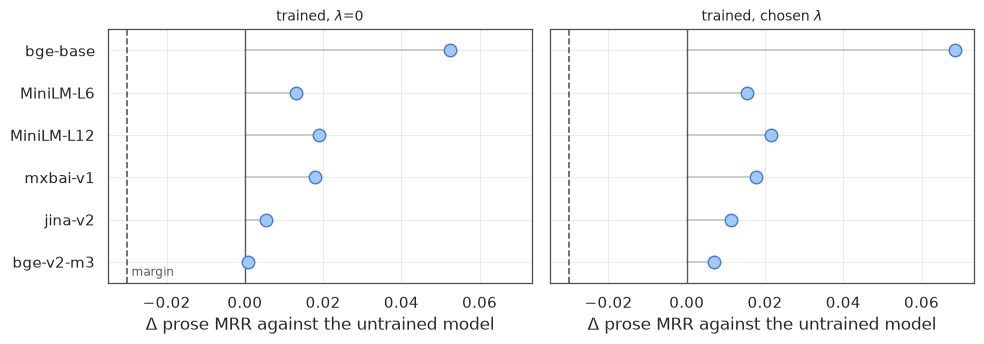

In [4]:
panels = [
    ("control", "trained, $\\lambda$=0"),
    ("winner", "trained, chosen $\\lambda$"),
]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True, sharex=True)
for ax, (condition, title) in zip(axs, panels, strict=True):
    point = prose.loc[order, f"{condition}_delta"]
    fill, edge = fills(prose.loc[order, "arms_kept"] == 10)
    for pos, value, f, e in zip(y, point, fill, edge, strict=True):
        ax.plot([0, value], [pos, pos], color="0.8", lw=1.4, zorder=1)
        ax.plot([value], [pos], marker="o", ms=9, mfc=f, mec=e, mew=1.0, zorder=3)
    ax.axvline(0, color=RULE, lw=1, zorder=2)
    ax.axvline(-NI_MARGIN, color=RULE, ls="--", lw=1.2, zorder=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(DELTA_LABEL)

axs[0].set_yticks(y)
axs[0].set_yticklabels(order)
axs[0].set_ylim(len(order) - 0.5, -0.5)
axs[0].text(
    -NI_MARGIN,
    len(order) - 0.6,
    " margin ",
    color=RULE,
    fontsize=8.5,
    ha="left",
    va="bottom",
)
save(fig, "nonbox_non_inferiority")

All sixty arms keep their ranking quality, the lowest interval bound among them
being -0.0061 against the -0.03 margin. The selected weight differs from the
rank-only control by at most +0.016, also inside the margin, so training for
format invariance on metadata passages costs nothing on prose that carries no
metadata block and gains nothing material there either.

## The invariance term

In [5]:
prose[["winner_gain", "gain_lo", "gain_hi", "gain_excludes_zero"]].round(4)

,winner_gain,gain_lo,gain_hi,gain_excludes_zero
model,,,,
MiniLM-L6,0.0021,-0.0018,0.0060,False
MiniLM-L12,0.0027,0.0006,0.0049,True
bge-base,0.0160,0.0105,0.0216,True
bge-v2-m3,0.0061,0.0021,0.0102,True
mxbai-v1,-0.0004,-0.0024,0.0016,False
jina-v2,0.0059,0.0036,0.0083,True


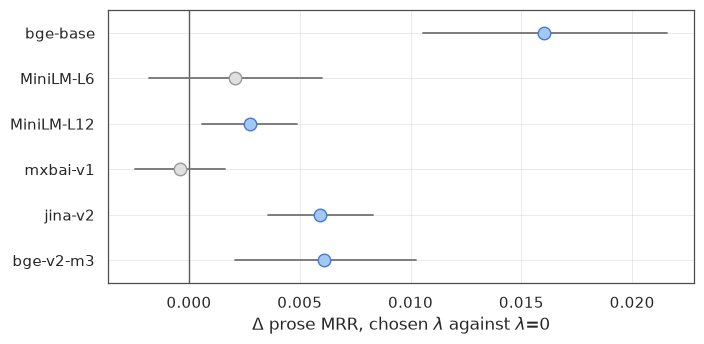

In [6]:
point = prose.loc[order, "winner_gain"]
fill, edge = fills(prose.loc[order, "gain_excludes_zero"])

fig, ax = plt.subplots(figsize=(7.2, 3.6))
for pos, value, low, high, f, e in zip(
    y,
    point,
    prose.loc[order, "gain_lo"],
    prose.loc[order, "gain_hi"],
    fill,
    edge,
    strict=True,
):
    ax.plot([low, high], [pos, pos], color=ERROR, lw=1.3, zorder=2)
    ax.plot([value], [pos], marker="o", ms=9, mfc=f, mec=e, mew=1.0, zorder=3)

ax.axvline(0, color=RULE, lw=1, zorder=1)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_ylim(len(order) - 0.5, -0.5)
ax.set_xlabel("$\\Delta$ prose MRR, chosen $\\lambda$ against $\\lambda$=0")
save(fig, "nonbox_invariance_term")

## Per fold

fold spread by model: MiniLM-L6 0.0046, MiniLM-L12 0.0045, bge-base 0.0048, bge-v2-m3 0.0030, mxbai-v1 0.0020, jina-v2 0.0033


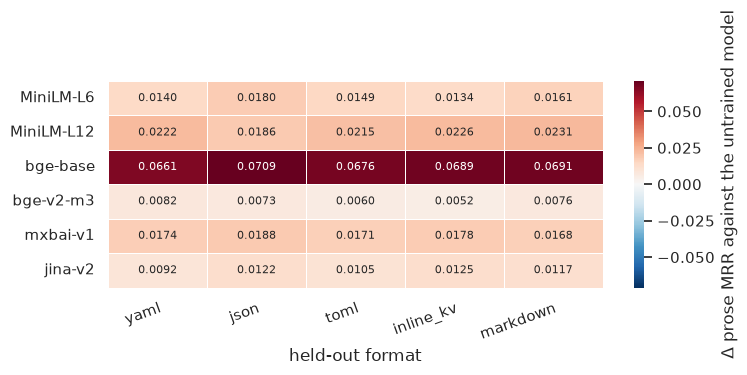

In [7]:
grid = prose_matrix(DATA_ROOT, SLUGS)
limit = np.abs(grid.to_numpy()).max()

fig, ax = plt.subplots(figsize=(7.6, 3.2))
sns.heatmap(
    grid,
    annot=True,
    fmt=".4f",
    cmap=DIVERGING,
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": DELTA_LABEL},
    ax=ax,
)
ax.set_xlabel("held-out format")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
save(fig, "nonbox_per_fold")

spread = grid.max(axis=1) - grid.min(axis=1)
print("fold spread by model: " + ", ".join(f"{m} {v:.4f}" for m, v in spread.items()))

The spread across the five folds is 0.002 (mxbai-v1) to 0.005 (bge-base), an
order below the 0.062 spread between models, so the absence of a capability cost
does not depend on which serialisation was withheld from training.